# Lección 1: Fundamentos de Big Data
## Proyecto: Retail Analytics Pipeline — RetailMax
### Módulo 9 · Bootcamp de Data Science · Talento Digital / Alkemy

---

**Contexto del proyecto:**

RetailMax es una empresa ficticia de e-commerce con millones de transacciones diarias, reseñas de clientes, registros de navegación y un catálogo de imágenes de productos. Para gestionar y aprovechar este volumen masivo de datos, RetailMax necesita construir un **pipeline de Big Data** robusto, escalable y orientado al aprendizaje automático.

A lo largo de este módulo construire este pipeline paso a paso. En esta **Lección 1** sentamos las bases conceptuales:
- ¿Qué es Big Data y por qué importa?
- ¿De dónde vienen los datos de RetailMax?
- ¿Cómo lucirá nuestra arquitectura?
- ¿Cómo es el dataset Fashion-MNIST que usaremos como proxy de imágenes de productos?

**Dataset:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) — 70 000 imágenes de prendas de ropa en escala de grises (28×28 píxeles), 10 categorías.

> **Cómo leer este notebook:** cada sección está numerada y conecta explícitamente con la siguiente. Las celdas de código incluyen comentarios línea a línea. Cuando hay fórmulas, se agrega la interpretación en palabras y un mini-ejemplo numérico.

---
## Sección 1: Las 5V de Big Data

El término **Big Data** no se refiere únicamente a «muchos datos». Se define por cinco dimensiones conocidas como las **5V**, que describen los desafíos y oportunidades que plantean los datos a gran escala.

Comprender las 5V es el primer paso para diseñar un pipeline adecuado: cada V nos dice *qué problema técnico debemos resolver* antes de siquiera pensar en modelos de ML.

---

### V1 · Volumen (*Volume*)

**Definición:** Cantidad total de datos generados y almacenados. Hablamos de Big Data cuando los datos superan la capacidad de procesamiento de una sola máquina (comúnmente a partir de los terabytes).

**Métrica clave:**
$$\text{Volumen total} = \text{registros} \times \text{tamaño promedio por registro}$$

*Interpretación:* Si cada transacción de RetailMax ocupa 500 bytes y se generan 5 millones de transacciones por día, el volumen diario es 5 000 000 × 500 B = **2,5 GB/día** → **~900 GB/año** solo de transacciones. Sumando imágenes, logs y reseñas, el total supera fácilmente el terabyte anual.

**RetailMax:**
- 5 millones de transacciones/día × 500 B = **2,5 GB/día**
- 200 000 imágenes de productos × 100 KB = **20 GB** en catálogo de imágenes
- Logs de navegación: ~50 GB/día

**Fashion-MNIST:**
- 70 000 imágenes × 28 × 28 píxeles × 1 byte = **~54 MB** en formato raw.
- Pequeño para Big Data, pero lo usaremos como *muestra representativa* del catálogo de imágenes de RetailMax.

---

### V2 · Velocidad (*Velocity*)

**Definición:** Ritmo al que los datos son generados, transmitidos y deben ser procesados. Hay dos modos principales:
- **Batch:** procesamiento diferido (por lotes, p. ej. cada hora o cada día).
- **Streaming / Real-time:** procesamiento continuo a medida que llegan los datos.

**Métrica clave:**
$$\text{Tasa de ingesta} = \frac{\text{registros}}{\text{unidad de tiempo}} \quad [\text{registros/segundo}]$$

*Interpretación:* 5 000 000 transacciones/día ÷ 86 400 segundos/día ≈ **58 transacciones/segundo** en promedio. En picos (Black Friday) ese número puede multiplicarse por 10 → **~580 tx/s**. Un sistema batch que procesa cada 24 h no detecta fraudes ni oportunidades en tiempo real.

**RetailMax:**
- Promedio: 58 tx/s
- Pico Black Friday: ~580 tx/s
- Clicks de navegación: >1 000 eventos/s durante horario pico

**Fashion-MNIST:**
- Dataset estático; la velocidad aplica cuando RetailMax sube nuevos productos: imagina 500 imágenes nuevas por hora que deben clasificarse automáticamente.

---

### V3 · Variedad (*Variety*)

**Definición:** Diversidad de formatos y tipos de datos. Se clasifica en tres categorías:

| Tipo | Descripción | Ejemplo RetailMax |
|------|-------------|-------------------|
| **Estructurado** | Tablas con esquema fijo | Transacciones (CSV/SQL) |
| **Semi-estructurado** | Esquema flexible | Logs JSON, reseñas XML |
| **No estructurado** | Sin esquema | Imágenes, texto libre, audio |

**Métrica clave:**
$$\text{Índice de variedad} = \frac{\text{número de fuentes distintas}}{\text{total de fuentes}} \times 100\%$$

*Interpretación:* Si RetailMax tiene 4 fuentes (transacciones, navegación, reseñas, imágenes) y las 4 tienen formatos distintos, el índice de variedad es 100% → necesitamos un pipeline capaz de ingestar **todos** los formatos.

**Fashion-MNIST:**
- Datos no estructurados (imágenes) que debemos convertir a tensores numéricos para poder procesarlos en Spark MLlib.

---

### V4 · Veracidad (*Veracity*)

**Definición:** Confiabilidad y calidad de los datos. Los datos reales contienen ruido, inconsistencias, valores faltantes y errores. La veracidad mide cuánto podemos confiar en los datos para tomar decisiones.

**Métrica clave:**
$$\text{Tasa de completitud} = \frac{\text{registros sin valores nulos}}{\text{total de registros}} \times 100\%$$

*Interpretación:* Si de 5 millones de transacciones, 250 000 tienen el campo `categoría` nulo, la tasa de completitud para ese campo es (4 750 000 / 5 000 000) × 100% = **95%**. Un pipeline de calidad debe detectar y corregir ese 5% antes de entrenar modelos.

**RetailMax:**
- Transacciones: ~2% con precio nulo (errores de sistema POS)
- Reseñas: ~15% sin calificación numérica (solo texto)
- Imágenes: ~3% corruptas o de baja resolución

**Fashion-MNIST:**
- Veracidad alta: dataset limpio, etiquetado manualmente por Zalando Research. Úsalo como referencia de «datos de calidad».

---

### V5 · Valor (*Value*)

**Definición:** Utilidad real que se extrae de los datos después de procesarlos. Es la V más importante: los datos sin análisis son solo costos de almacenamiento.

**Métrica clave (ROI de datos):**
$$\text{ROI}_{\text{datos}} = \frac{\text{beneficio generado por insights} - \text{costo del pipeline}}{\text{costo del pipeline}} \times 100\%$$

*Interpretación:* Si el pipeline cuesta 50 000 USD/año y los modelos de recomendación generan 500 000 USD adicionales en ventas, el ROI es (500 000 − 50 000) / 50 000 × 100% = **900%**.

**RetailMax — ejemplos de valor:**
- Recomendaciones personalizadas → +15% en conversión
- Detección de fraude en tiempo real → −30% en chargebacks
- Clasificación automática de imágenes → −80% en tiempo de catalogación

**Fashion-MNIST:**
- Un clasificador de prendas con 90%+ de accuracy puede automatizar la catalogación de miles de productos nuevos por día → valor directo para RetailMax.

---

> **Conexión con la Sección 2:** Ahora que entendemos *qué* desafíos plantea el Big Data, necesitamos identificar *de dónde vienen* los datos de RetailMax para mapear cada fuente con la V que más la afecta.

---
## Sección 2: Fuentes de Datos de RetailMax

Un pipeline de Big Data comienza siempre por entender las **fuentes de datos**: quién las genera, en qué formato llegan, qué volumen tienen y qué V de Big Data las caracteriza mejor.

RetailMax tiene cuatro grandes fuentes de datos:

1. **Transacciones** — registros de compra-venta (structured data)
2. **Navegación** — clicks, sesiones, tiempo en página (semi-structured)
3. **Reseñas** — opiniones de clientes en texto libre (unstructured)
4. **Imágenes de productos** — fotos del catálogo (Fashion-MNIST como proxy)

En la celda de código siguiente creamos un inventario de estas fuentes en Python.

In [1]:
# ============================================================
# Sección 2: Fuentes de datos de RetailMax
# ============================================================
# Importamos pandas para crear y mostrar la tabla resumen

import pandas as pd

# ----------------------------------------------------------
# Paso 1: Definir el inventario de fuentes como lista de dicts
# Cada diccionario representa una fuente de datos distinta.
# ----------------------------------------------------------
fuentes_datos = [
    {
        "Fuente": "Transacciones de compra",
        "Tipo": "Estructurado",
        "Volumen estimado": "5M registros/día · ~2.5 GB/día",
        "Formato": "CSV / SQL (PostgreSQL)",
        "V principal": "Volumen + Velocidad",
        "Descripción": "ID pedido, producto, precio, cliente, timestamp, método de pago"
    },
    {
        "Fuente": "Logs de navegación",
        "Tipo": "Semi-estructurado",
        "Volumen estimado": "50M eventos/día · ~50 GB/día",
        "Formato": "JSON (Kafka topics)",
        "V principal": "Velocidad + Variedad",
        "Descripción": "Clicks, scroll depth, tiempo en página, carrito abandonado"
    },
    {
        "Fuente": "Reseñas de clientes",
        "Tipo": "No estructurado",
        "Volumen estimado": "200K reseñas/mes · ~1 GB/mes",
        "Formato": "Texto libre (MongoDB)",
        "V principal": "Variedad + Veracidad",
        "Descripción": "Texto de la reseña, calificación (1-5), idioma, fecha"
    },
    {
        "Fuente": "Imágenes de productos (Fashion-MNIST proxy)",
        "Tipo": "No estructurado",
        "Volumen estimado": "70K imágenes · ~54 MB (dataset) / 200K imgs en prod",
        "Formato": "PNG/JPEG → tensores 28×28",
        "V principal": "Variedad + Valor",
        "Descripción": "Foto del producto, categoría etiquetada (10 clases)"
    }
]

# ----------------------------------------------------------
# Paso 2: Convertir la lista de dicts en un DataFrame de pandas
# El DataFrame es nuestra tabla resumen legible.
# ----------------------------------------------------------
df_fuentes = pd.DataFrame(fuentes_datos)

# ----------------------------------------------------------
# Paso 3: Configurar pandas para mostrar texto completo
# Sin esto, las columnas largas aparecen truncadas con '...'.
# ----------------------------------------------------------
pd.set_option('display.max_colwidth', 60)   # ancho máximo de columna
pd.set_option('display.width', 200)          # ancho total del display

# ----------------------------------------------------------
# Paso 4: Mostrar la tabla resumen
# ----------------------------------------------------------
print("=" * 80)
print("INVENTARIO DE FUENTES DE DATOS — RetailMax")
print("=" * 80)
print(df_fuentes[['Fuente', 'Tipo', 'Volumen estimado', 'Formato', 'V principal']].to_string(index=False))

# ----------------------------------------------------------
# Paso 5: Calcular el volumen total diario estimado (solo las
# fuentes con datos diarios) para ilustrar el Volumen (V1).
# ----------------------------------------------------------
volumen_diario_gb = {
    "Transacciones":    2.5,   # GB/día
    "Logs navegación":  50.0,  # GB/día
    "Reseñas":          0.033, # ~1 GB/mes ÷ 30 días
    "Imágenes (nuevas)": 1.0   # estimado producción
}

total_diario = sum(volumen_diario_gb.values())  # suma de todos los volúmenes
total_anual  = total_diario * 365               # proyección anual

print("\n" + "=" * 80)
print("ESTIMACIÓN DE VOLUMEN TOTAL")
print("=" * 80)
for fuente, gb in volumen_diario_gb.items():
    print(f"  {fuente:<25} → {gb:.2f} GB/día")
print("-" * 80)
print(f"  {'TOTAL DIARIO':<25} → {total_diario:.2f} GB/día")
print(f"  {'TOTAL ANUAL (estimado)':<25} → {total_anual:.1f} GB/año  ({total_anual/1024:.2f} TB/año)")
print("=" * 80)

INVENTARIO DE FUENTES DE DATOS — RetailMax
                                     Fuente              Tipo                                    Volumen estimado                   Formato          V principal
                    Transacciones de compra      Estructurado                      5M registros/día · ~2.5 GB/día    CSV / SQL (PostgreSQL)  Volumen + Velocidad
                         Logs de navegación Semi-estructurado                        50M eventos/día · ~50 GB/día       JSON (Kafka topics) Velocidad + Variedad
                        Reseñas de clientes   No estructurado                        200K reseñas/mes · ~1 GB/mes     Texto libre (MongoDB) Variedad + Veracidad
Imágenes de productos (Fashion-MNIST proxy)   No estructurado 70K imágenes · ~54 MB (dataset) / 200K imgs en prod PNG/JPEG → tensores 28×28     Variedad + Valor

ESTIMACIÓN DE VOLUMEN TOTAL
  Transacciones             → 2.50 GB/día
  Logs navegación           → 50.00 GB/día
  Reseñas                   → 0.03 GB/

> **Interpretación del volumen:** RetailMax genera aproximadamente **53,5 GB por día** entre todas sus fuentes, lo que equivale a **~19,5 TB por año**. Esto confirma que estamos ante un caso real de Big Data y justifica el uso de Apache Spark (que veremos en la Lección 2).

> **Conexión con la Sección 3:** Identificadas las fuentes, ahora necesitamos un **plano arquitectónico** que muestre cómo fluyen esos datos desde su origen hasta los modelos de ML y las aplicaciones de marketing.

---
## Sección 3: Arquitectura del Pipeline

Un **pipeline de datos** es la secuencia de etapas por las que pasan los datos: desde las fuentes brutas hasta los resultados accionables. La arquitectura define *qué tecnología* se usa en cada etapa y *cómo se conectan*.

Para RetailMax proponemos la siguiente arquitectura de **5 capas**, basada en el stack Apache Spark:

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    ARQUITECTURA — RETAILMAX DATA PIPELINE                   │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  CAPA 1: FUENTES DE DATOS (origen de la información)                        │
│  ┌─────────────┐  ┌──────────────┐  ┌────────────┐  ┌──────────────────┐    │
│  │Transacciones│  │ Logs JSON    │  │  Reseñas   │  │Imágenes Productos│    │
│  │  CSV / SQL  │  │  (Kafka)     │  │ (MongoDB)  │  │ Fashion-MNIST    │    │
│  └──────┬──────┘  └──────┬───────┘  └─────┬──────┘  └────────┬─────────┘    │
│         └────────────────┴──────────────── ┴─────────────────┘              │
│                                    │                                        │
│                                    ▼                                        │
│  CAPA 2: INGESTA (recepción y carga de datos)                               │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │          Apache Spark — SparkContext / SparkSession                 │    │
│  │     (lectura batch desde HDFS/S3 + streaming desde Kafka)           │    │
│  └────────────────────────────────┬────────────────────────────────────┘    │
│                                   │                                         │
│                                   ▼                                         │
│  CAPA 3: PROCESAMIENTO (limpieza, transformación, feature engineering)      │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │   Spark RDDs (operaciones distribuidas de bajo nivel)               │    │
│  │   Spark DataFrames + Spark SQL (transformaciones declarativas)      │    │
│  │   Spark Streaming (procesamiento en tiempo real)                    │    │
│  └────────────────────────────────┬────────────────────────────────────┘    │
│                                   │                                         │
│                                   ▼                                         │
│  CAPA 4: ALMACENAMIENTO (persistencia eficiente)                            │
│  ┌─────────────────────────────────────────────────────────────────────┐    │
│  │   Formato Parquet (columnar, comprimido, compatible con Spark/Hive) │    │
│  │   Data Lake en HDFS o Amazon S3                                     │    │
│  │   Hive Metastore para catalogación de tablas                        │    │
│  └────────────────────────────────┬────────────────────────────────────┘    │
│                                   │                                         │
│                                   ▼                                         │
│  CAPA 5: ML Y RESULTADOS (entrenamiento, predicción, entrega)               │
│  ┌──────────────────────────┐    ┌──────────────────────────────────────┐   │
│  │ Spark MLlib              │    │  Aplicaciones de negocio             │   │
│  │ (clasificación imágenes, │──▶ │ · Motor de recomendaciones          │   │
│  │  análisis de sentimiento,│    │ · Dashboard de ventas (BI)           │   │
│  │  detección de fraude)    │    │ · Campañas de marketing personaliz.  │   │
│  └──────────────────────────┘    └──────────────────────────────────────┘   │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Descripción de cada capa:**

| Capa | Tecnología | Propósito |
|------|------------|-----------|
| 1 — Fuentes | CSV, JSON, MongoDB, imágenes | Origen heterogéneo de los datos |
| 2 — Ingesta | Apache Spark (SparkSession) | Leer y distribuir datos en el clúster |
| 3 — Procesamiento | RDDs, DataFrames, Spark SQL | Limpiar, transformar y enriquecer |
| 4 — Almacenamiento | Parquet + HDFS/S3 | Guardar de forma eficiente y reutilizable |
| 5 — ML / Resultados | MLlib + dashboards | Generar predicciones y valor de negocio |

> **Conexión con la Sección 4:** Antes de implementar el pipeline completo, necesitamos conocer en profundidad nuestro dataset de imágenes. La siguiente sección hace un análisis exploratorio de Fashion-MNIST para entender con qué datos trabajaremos.

In [2]:
# ============================================================
# Sección 3 (código): Imprimir el diagrama de arquitectura
# ============================================================
# Este bloque imprime el diagrama ASCII de forma visual.
# Útil para incluirlo en reportes o terminales sin soporte Markdown.

diagrama = """
╔══════════════════════════════════════════════════════════════════════════════╗
║             RETAILMAX DATA PIPELINE — ARQUITECTURA DE 5 CAPAS                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  [CAPA 1]  FUENTES DE DATOS                                                  ║
║  Transacciones(CSV) | Logs(JSON/Kafka) | Reseñas(MongoDB) | Imágenes(MNIST)  ║
║                              │                                               ║
║                              ▼                                               ║
║  [CAPA 2]  INGESTA                                                           ║
║            Apache Spark — SparkSession (batch + streaming)                   ║
║                              │                                               ║
║                              ▼                                               ║
║  [CAPA 3]  PROCESAMIENTO                                                     ║
║            RDDs → DataFrames → Spark SQL → Spark Streaming                   ║
║                              │                                               ║
║                              ▼                                               ║
║  [CAPA 4]  ALMACENAMIENTO                                                    ║
║            Formato Parquet en Data Lake (HDFS / Amazon S3)                   ║
║                              │                                               ║
║                              ▼                                               ║
║  [CAPA 5]  ML + RESULTADOS                                                   ║
║            Spark MLlib  ──▶  Recomendaciones | Fraude | BI | Marketing      ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# Imprimir el diagrama en la salida estándar
print(diagrama)

# ----------------------------------------------------------
# Descripción textual de cada capa para referencia rápida
# ----------------------------------------------------------
capas = [
    ("CAPA 1 — Fuentes",        "CSV, JSON, MongoDB, imágenes PNG/JPEG"),
    ("CAPA 2 — Ingesta",        "SparkSession: sc.textFile(), spark.read.json(), etc."),
    ("CAPA 3 — Procesamiento",  "RDD.map/filter, DataFrame.groupBy, Spark SQL SELECT"),
    ("CAPA 4 — Almacenamiento", "df.write.parquet('s3://retailmax/processed/')"),
    ("CAPA 5 — ML/Resultados",  "MLlib Pipeline: clasificación, regresión, clustering"),
]

print(f"{'Capa':<30} {'Tecnología / Comando ejemplo':<50}")
print("-" * 80)
for nombre, tecnologia in capas:
    # f-string con alineación: :<30 = alinear a la izquierda en 30 caracteres
    print(f"{nombre:<30} {tecnologia:<50}")


╔══════════════════════════════════════════════════════════════════════════════╗
║             RETAILMAX DATA PIPELINE — ARQUITECTURA DE 5 CAPAS                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  [CAPA 1]  FUENTES DE DATOS                                                  ║
║  Transacciones(CSV) | Logs(JSON/Kafka) | Reseñas(MongoDB) | Imágenes(MNIST)  ║
║                              │                                               ║
║                              ▼                                               ║
║  [CAPA 2]  INGESTA                                                           ║
║            Apache Spark — SparkSession (batch + streaming)                   ║
║                              │                                               ║
║                              ▼                                               ║
║  [CAPA 3]  PROCESAMIENTO 

---
## Sección 4: Análisis Exploratorio de Fashion-MNIST

Fashion-MNIST es nuestro dataset de trabajo: 70 000 imágenes en escala de grises (28×28 píxeles) de 10 categorías de prendas de ropa. Lo usaremos como **proxy del catálogo de imágenes de RetailMax**.

Antes de construir cualquier modelo, debemos hacer un **Análisis Exploratorio de Datos (EDA)** para:
- Confirmar el tamaño y estructura del dataset (V1: Volumen)
- Verificar la calidad de los datos (V4: Veracidad)
- Entender la distribución de clases
- Visualizar ejemplos reales

Los siguientes pasos están numerados y cada uno construye sobre el anterior.

In [3]:
# ============================================================
# Sección 4: Análisis Exploratorio de Fashion-MNIST
# ============================================================

# ----------------------------------------------------------
# Paso 1: Importar librerías necesarias
# ----------------------------------------------------------
import numpy as np                        # operaciones numéricas sobre arrays
import matplotlib.pyplot as plt           # visualizaciones gráficas
import matplotlib.gridspec as gridspec    # layout de subplots
import warnings
warnings.filterwarnings('ignore')         # suprimir advertencias de versiones

# Intentamos cargar Fashion-MNIST desde TensorFlow/Keras.
# Si no está disponible, usamos scikit-learn como alternativa.
try:
    # Opción A: TensorFlow/Keras 
    from tensorflow.keras.datasets import fashion_mnist
    LOADER = 'TENSORFLOW'
    print("Paso 1  — Usando TensorFlow/Keras para cargar Fashion-MNIST")
except ImportError:
    try:
        # Opción B: PyTorch / torchvision
        import torchvision
        import torchvision.transforms as transforms
        LOADER = 'TORCH'
        print("Paso 1  — Usando PyTorch/torchvision para cargar Fashion-MNIST")
    except ImportError:
        # Opción C: scikit-learn (fetch desde OpenML — requiere internet)
        from sklearn.datasets import fetch_openml
        LOADER = 'SKLEARN'
        print("Paso 1 — Usando scikit-learn (OpenML) para cargar Fashion-MNIST")

print(f"   Loader seleccionado: {LOADER}")

Paso 1  — Usando TensorFlow/Keras para cargar Fashion-MNIST
   Loader seleccionado: TENSORFLOW


In [4]:
# ----------------------------------------------------------
# Paso 2: Cargar el dataset según el loader disponible
# ----------------------------------------------------------
print("Paso 2 — Cargando Fashion-MNIST...")

if LOADER == 'TENSORFLOW':
    # fashion_mnist.load_data() devuelve tuplas (X_train, y_train), (X_test, y_test)
    # X: arrays de imágenes en escala de grises (valores 0-255)
    # y: etiquetas numéricas (0-9)
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

elif LOADER == 'TORCH':
    # Descarga y carga el dataset desde los servidores de Zalando
    transform = transforms.ToTensor()  # convierte PIL Image a tensor [0,1]
    train_ds = torchvision.datasets.FashionMNIST(
        root='./data', train=True,  download=True, transform=transform
    )
    test_ds = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    # Convertir a arrays numpy para uniformidad con el resto del código
    X_train = np.array([img.numpy().squeeze() for img, _ in train_ds])
    y_train = np.array([label for _, label in train_ds])
    X_test  = np.array([img.numpy().squeeze() for img, _ in test_ds])
    y_test  = np.array([label for _, label in test_ds])
    # Escalar de [0,1] a [0,255] para consistencia
    X_train = (X_train * 255).astype(np.uint8)
    X_test  = (X_test  * 255).astype(np.uint8)

elif LOADER == 'SKLEARN':
    # Descarga desde OpenML (ID 40996 = Fashion-MNIST)
    fmnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')
    X_all = fmnist.data.reshape(-1, 28, 28).astype(np.uint8)  # (70000, 28, 28)
    y_all = fmnist.target.astype(int)
    # Split manual: 60K train, 10K test (igual que el original)
    X_train, X_test = X_all[:60000], X_all[60000:]
    y_train, y_test = y_all[:60000], y_all[60000:]

# Concatenar train + test para estadísticas globales
X_all = np.concatenate([X_train, X_test], axis=0)  # (70000, 28, 28)
y_all = np.concatenate([y_train, y_test], axis=0)  # (70000,)

print(f"   Dataset cargado exitosamente.")

Paso 2 — Cargando Fashion-MNIST...
   Dataset cargado exitosamente.


In [5]:
# ----------------------------------------------------------
# Paso 3: Explorar la estructura del dataset (shape y clases)
# ----------------------------------------------------------
print("Paso 3 — Estructura del dataset")
print("=" * 55)

# Nombre de las 10 clases (índice = etiqueta numérica)
nombres_clases = [
    "T-shirt/Top",   # 0
    "Pantalón",      # 1
    "Jersey/Suéter", # 2
    "Vestido",       # 3
    "Abrigo",        # 4
    "Sandalia",      # 5
    "Camisa",        # 6
    "Zapatilla",     # 7
    "Bolso",         # 8
    "Botín/Bota"     # 9
]

num_clases = len(nombres_clases)  # 10 categorías

# Mostrar forma de los arrays
print(f"  X_train shape  : {X_train.shape}  → (muestras, alto_px, ancho_px)")
print(f"  y_train shape  : {y_train.shape}  → (muestras)")
print(f"  X_test  shape  : {X_test.shape}   → (muestras, alto_px, ancho_px)")
print(f"  y_test  shape  : {y_test.shape}   → (muestras)")
print(f"  Total imágenes : {len(X_all):,}")
print(f"  Número de clases: {num_clases}")
print()
print("  Clases disponibles:")
for i, nombre in enumerate(nombres_clases):
    # Contar cuántas imágenes hay de cada clase
    count = np.sum(y_all == i)           # número de imágenes de esta clase
    pct   = count / len(y_all) * 100     # porcentaje del total
    print(f"    [{i}] {nombre:<20} → {count:,} imágenes ({pct:.1f}%)")
print("=" * 55)

Paso 3 — Estructura del dataset
  X_train shape  : (60000, 28, 28)  → (muestras, alto_px, ancho_px)
  y_train shape  : (60000,)  → (muestras)
  X_test  shape  : (10000, 28, 28)   → (muestras, alto_px, ancho_px)
  y_test  shape  : (10000,)   → (muestras)
  Total imágenes : 70,000
  Número de clases: 10

  Clases disponibles:
    [0] T-shirt/Top          → 7,000 imágenes (10.0%)
    [1] Pantalón             → 7,000 imágenes (10.0%)
    [2] Jersey/Suéter        → 7,000 imágenes (10.0%)
    [3] Vestido              → 7,000 imágenes (10.0%)
    [4] Abrigo               → 7,000 imágenes (10.0%)
    [5] Sandalia             → 7,000 imágenes (10.0%)
    [6] Camisa               → 7,000 imágenes (10.0%)
    [7] Zapatilla            → 7,000 imágenes (10.0%)
    [8] Bolso                → 7,000 imágenes (10.0%)
    [9] Botín/Bota           → 7,000 imágenes (10.0%)


In [6]:
# ----------------------------------------------------------
# Paso 4: Estadísticas básicas de los píxeles
# ----------------------------------------------------------
print("Paso 4 — Estadísticas de los valores de píxel")
print("=" * 55)
# Los píxeles son valores enteros en el rango [0, 255]
# 0 = negro (fondo), 255 = blanco (máxima intensidad)

px_min    = X_all.min()               # valor mínimo de píxel
px_max    = X_all.max()               # valor máximo de píxel
px_media  = X_all.mean()              # promedio global de todos los píxeles
px_std    = X_all.std()               # desviación estándar
px_mediana= np.median(X_all)          # mediana (valor central)

print(f"  Mínimo de píxel  : {px_min}   (fondo negro puro)")
print(f"  Máximo de píxel  : {px_max} (blanco puro)")
print(f"  Media global     : {px_media:.2f}")
print(f"  Desv. estándar   : {px_std:.2f}")
print(f"  Mediana          : {px_mediana:.1f}")
print()
# Interpretación
print("  Interpretación:")
print(f"  → La media de {px_media:.1f} indica que la mayoría del fondo")
print(f"    es oscuro (tendencia a 0). Las prendas ocupan una")
print(f"    fracción del espacio de la imagen.")
print(f"  → La std de {px_std:.1f} refleja alta variabilidad: hay zonas")
print(f"    completamente negras (fondo) y zonas muy brillantes (prenda).")
print("=" * 55)

# Mini-ejemplo numérico: normalización Z-score
print()
print("  Mini-ejemplo — Normalización Z-score de un píxel:")
print("  Fórmula: z = (x - media) / std")
px_ejemplo = 200  # valor de ejemplo (píxel brillante de una prenda)
z = (px_ejemplo - px_media) / px_std
print(f"  Píxel = {px_ejemplo}  →  z = ({px_ejemplo} − {px_media:.2f}) / {px_std:.2f} = {z:.2f}")
print(f"  Interpretación: ese píxel está {z:.2f} desviaciones estándar")
print(f"  por encima de la media global → pertenece a la zona brillante de la prenda.")

Paso 4 — Estadísticas de los valores de píxel
  Mínimo de píxel  : 0   (fondo negro puro)
  Máximo de píxel  : 255 (blanco puro)
  Media global     : 72.97
  Desv. estándar   : 90.00
  Mediana          : 0.0

  Interpretación:
  → La media de 73.0 indica que la mayoría del fondo
    es oscuro (tendencia a 0). Las prendas ocupan una
    fracción del espacio de la imagen.
  → La std de 90.0 refleja alta variabilidad: hay zonas
    completamente negras (fondo) y zonas muy brillantes (prenda).

  Mini-ejemplo — Normalización Z-score de un píxel:
  Fórmula: z = (x - media) / std
  Píxel = 200  →  z = (200 − 72.97) / 90.00 = 1.41
  Interpretación: ese píxel está 1.41 desviaciones estándar
  por encima de la media global → pertenece a la zona brillante de la prenda.


Paso 5 — Generando cuadrícula 5×5 de ejemplos...


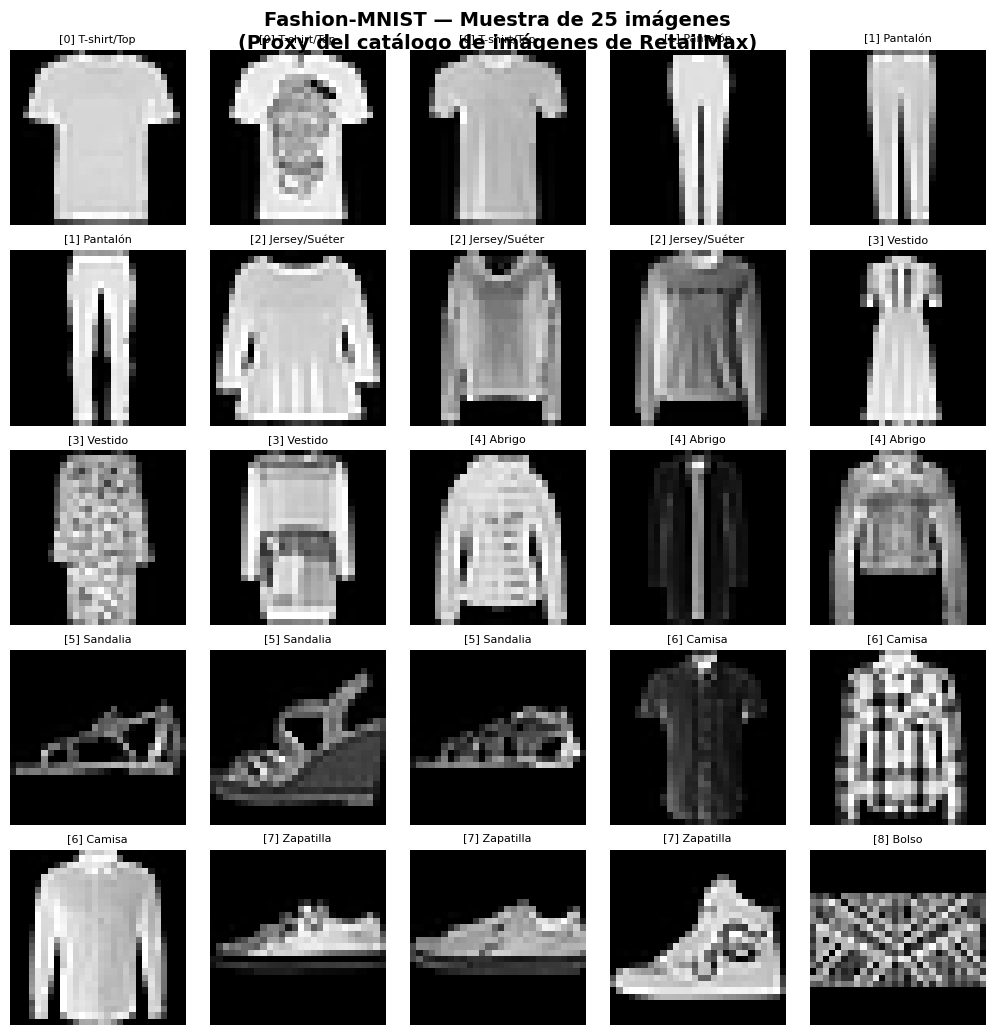

   Cuadrícula guardada como 'fashion_mnist_muestra.png'


In [7]:
# ----------------------------------------------------------
# Paso 5: Visualizar cuadrícula 5×5 con ejemplos de imágenes
# ----------------------------------------------------------
print("Paso 5 — Generando cuadrícula 5×5 de ejemplos...")

# Configurar la figura: 5 filas × 5 columnas = 25 imágenes de ejemplo
fig, axes = plt.subplots(
    nrows=5, ncols=5,
    figsize=(10, 10),       # tamaño total de la figura en pulgadas
    constrained_layout=True # espaciado automático entre subplots
)

# Título general de la figura
fig.suptitle(
    "Fashion-MNIST — Muestra de 25 imágenes\n"
    "(Proxy del catálogo de imágenes de RetailMax)",
    fontsize=14, fontweight='bold', y=1.02
)

# Seleccionar 25 imágenes: una por clase (2 veces para completar 25, con variedad)
# Usamos np.random.seed para reproducibilidad
np.random.seed(42)  # seed fija → los mismos índices en cada ejecución

# Elegir índices: para cada clase tomamos varias muestras aleatorias
indices_por_clase = []
for clase in range(10):
    idx_clase = np.where(y_train == clase)[0]   # índices de esta clase en train
    muestra   = np.random.choice(idx_clase, 3)  # 3 muestras aleatorias por clase
    indices_por_clase.extend(muestra.tolist())

# Tomar solo 25 de los 30 índices generados
indices_muestra = indices_por_clase[:25]

# Dibujar cada imagen en su subgráfica correspondiente
for idx_plot, idx_data in enumerate(indices_muestra):
    fila = idx_plot // 5   # fila en la cuadrícula (0-4)
    col  = idx_plot % 5    # columna en la cuadrícula (0-4)
    ax   = axes[fila, col] # subgráfica en posición (fila, col)

    # Mostrar la imagen en escala de grises
    ax.imshow(X_train[idx_data], cmap='gray', vmin=0, vmax=255)

    # Etiqueta: nombre de la clase
    clase_num    = y_train[idx_data]         # número de clase (0-9)
    clase_nombre = nombres_clases[clase_num] # nombre legible
    ax.set_title(f"[{clase_num}] {clase_nombre}", fontsize=8)

    # Quitar los ejes (números de coordenadas) para limpiar la visualización
    ax.axis('off')

plt.savefig('fashion_mnist_muestra.png', dpi=120, bbox_inches='tight')
plt.show()
print("   Cuadrícula guardada como 'fashion_mnist_muestra.png'")

In [8]:
# ----------------------------------------------------------
# Paso 6: Calcular el tamaño total del dataset en MB
# ----------------------------------------------------------
print("Paso 6 — Cálculo del tamaño del dataset en memoria")
print("=" * 55)

# X_all.nbytes devuelve el número total de bytes del array numpy
bytes_imagenes = X_all.nbytes                   # bytes totales de las imágenes
bytes_etiquetas = y_all.nbytes                  # bytes totales de las etiquetas
bytes_total = bytes_imagenes + bytes_etiquetas  # suma total

# Convertir a MB (1 MB = 1024² bytes = 1,048,576 bytes)
mb_imagenes  = bytes_imagenes  / (1024 ** 2)
mb_etiquetas = bytes_etiquetas / (1024 ** 2)
mb_total     = bytes_total     / (1024 ** 2)

print(f"  Forma X_all    : {X_all.shape}  → dtype: {X_all.dtype}")
print(f"  Bytes/imagen   : 28 × 28 × 1 byte = {28*28} bytes")
print()
print(f"  Tamaño imágenes : {bytes_imagenes:,} bytes = {mb_imagenes:.2f} MB")
print(f"  Tamaño etiquetas: {bytes_etiquetas:,} bytes = {mb_etiquetas:.4f} MB")
print(f"  TOTAL en memoria: {bytes_total:,} bytes = {mb_total:.2f} MB")
print()

# Comparación con el catálogo real de RetailMax (estimado)
imagenes_retailmax = 200_000                           # estimado de imágenes en catálogo de RetailMax
bytes_retailmax_raw = imagenes_retailmax * 28 * 28     # si fueran 28x28 px raw
mb_retailmax_raw    = bytes_retailmax_raw / (1024**2)

# En producción las imágenes son JPEG de ~100 KB
mb_retailmax_jpeg   = imagenes_retailmax * 100 / 1024  # 100 KB × 200K imágenes

print(f"  Proyección RetailMax ({imagenes_retailmax:,} imágenes):")
print(f"    → Formato raw 28×28: {mb_retailmax_raw:.1f} MB")
print(f"    → Formato JPEG ~100KB: {mb_retailmax_jpeg/1024:.1f} GB")
print()
print("  Conclusión: Fashion-MNIST cabe en RAM de cualquier PC.")
print("  El catálogo real de RetailMax (~20 GB) ya requiere procesamiento")
print("  distribuido → justifica el uso de Apache Spark (Lección 2).")
print("=" * 55)

Paso 6 — Cálculo del tamaño del dataset en memoria
  Forma X_all    : (70000, 28, 28)  → dtype: uint8
  Bytes/imagen   : 28 × 28 × 1 byte = 784 bytes

  Tamaño imágenes : 54,880,000 bytes = 52.34 MB
  Tamaño etiquetas: 70,000 bytes = 0.0668 MB
  TOTAL en memoria: 54,950,000 bytes = 52.40 MB

  Proyección RetailMax (200,000 imágenes):
    → Formato raw 28×28: 149.5 MB
    → Formato JPEG ~100KB: 19.1 GB

  Conclusión: Fashion-MNIST cabe en RAM de cualquier PC.
  El catálogo real de RetailMax (~20 GB) ya requiere procesamiento
  distribuido → justifica el uso de Apache Spark (Lección 2).


Paso 7 — Distribución de clases (balance del dataset)


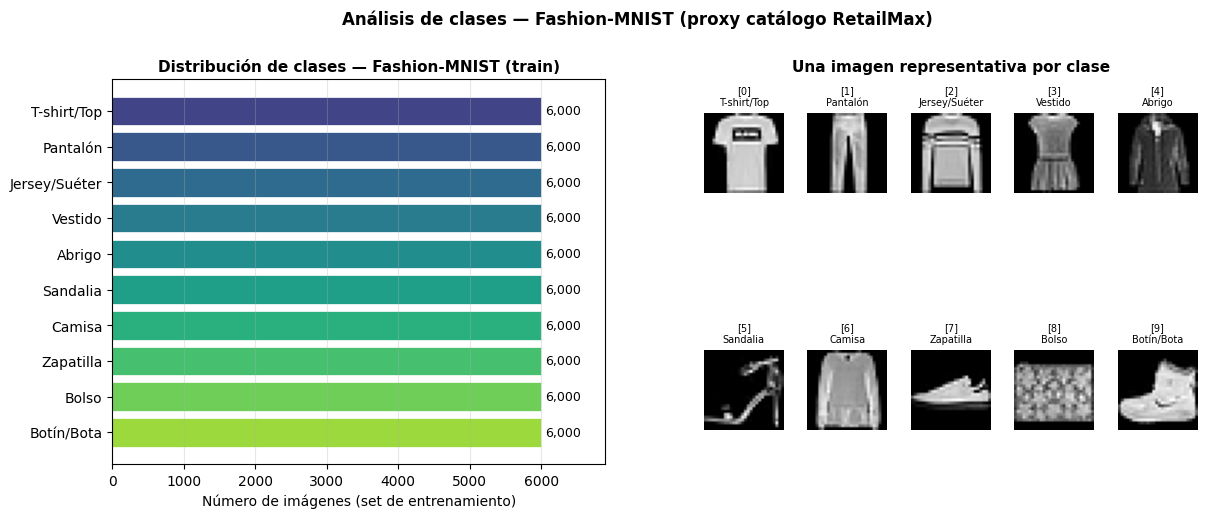

   Gráfico guardado como 'fashion_mnist_clases.png'

   Observación: el dataset está BALANCEADO (6000 imágenes/clase en train).
   Esto simplifica el entrenamiento de modelos (no necesitamos oversampling).
   En datos reales de RetailMax, las categorías NO estarán balanceadas.


In [9]:
# ----------------------------------------------------------
# Paso 7: Distribución de clases y visualización adicional
# ----------------------------------------------------------
print("Paso 7 — Distribución de clases (balance del dataset)")

# Contar imágenes por clase en el conjunto de entrenamiento
conteo_clases = {}
for clase in range(10):
    conteo_clases[nombres_clases[clase]] = int(np.sum(y_train == clase))

# Crear figura con dos subgráficas: barra de frecuencia + imagen de referencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Barras horizontales de frecuencia por clase ---
clases  = list(conteo_clases.keys())    # nombres de clases
conteos = list(conteo_clases.values())  # conteos correspondientes

# Barras horizontales con colores del mapa 'viridis'
colores = plt.cm.viridis(np.linspace(0.2, 0.85, len(clases)))
bars = ax1.barh(clases, conteos, color=colores, edgecolor='white', linewidth=0.5)

# Añadir el valor numérico al final de cada barra
for bar, valor in zip(bars, conteos):
    ax1.text(
        bar.get_width() + 50,             # posición x (justo después de la barra)
        bar.get_y() + bar.get_height()/2, # posición y (centro vertical de la barra)
        f'{valor:,}',                     # texto con formato de miles
        va='center', fontsize=9
    )

ax1.set_xlabel('Número de imágenes (set de entrenamiento)', fontsize=10)
ax1.set_title('Distribución de clases — Fashion-MNIST (train)', fontsize=11, fontweight='bold')
ax1.set_xlim(0, max(conteos) * 1.15)  # espacio para las etiquetas
ax1.invert_yaxis()                    # clase 0 arriba (orden natural)
ax1.grid(axis='x', alpha=0.3)         # líneas de guía horizontales sutiles

# --- Gráfico 2: Un ejemplo por clase ---
ax2.set_title('Una imagen representativa por clase', fontsize=11, fontweight='bold')
ax2.axis('off')                       # ocultar ejes del contenedor

# Crear mini-subgráficas dentro de ax2 usando GridSpec
gs_inner = gridspec.GridSpecFromSubplotSpec(
    2, 5,                             # 2 filas × 5 columnas = 10 celdas
    subplot_spec=ax2.get_subplotspec(),
    hspace=0.6, wspace=0.3
)

for i in range(10):
    # Buscar la primera imagen de la clase i en el set de entrenamiento
    idx_primera = np.where(y_train == i)[0][0]   # índice de la primera imagen de clase i
    sub_ax = fig.add_subplot(gs_inner[i])        # subgráfica en posición i
    sub_ax.imshow(X_train[idx_primera], cmap='gray', vmin=0, vmax=255)
    sub_ax.set_title(f"[{i}]\n{nombres_clases[i]}", fontsize=7)
    sub_ax.axis('off')

plt.suptitle(
    "Análisis de clases — Fashion-MNIST (proxy catálogo RetailMax)",
    fontsize=12, fontweight='bold', y=1.02
)
plt.savefig('fashion_mnist_clases.png', dpi=120, bbox_inches='tight')
plt.show()
print("   Gráfico guardado como 'fashion_mnist_clases.png'")
print()
print("   Observación: el dataset está BALANCEADO (6000 imágenes/clase en train).")
print("   Esto simplifica el entrenamiento de modelos (no necesitamos oversampling).")
print("   En datos reales de RetailMax, las categorías NO estarán balanceadas.")

---
## Sección 5: Informe Conceptual

### Resumen ejecutivo

En esta lección establecimos los cimientos conceptuales del proyecto **Retail Analytics Pipeline** para RetailMax:

1. **Comprendimos las 5V de Big Data** y las aplicamos al contexto real de RetailMax, con ejemplos numéricos concretos (58 tx/s en promedio, ~19,5 TB/año, etc.).
2. **Inventariamos las fuentes de datos** de RetailMax (transacciones, logs de navegación, reseñas e imágenes) y las organizamos en una tabla estructurada con pandas.
3. **Propusimos una arquitectura de 5 capas** (Fuentes → Ingesta → Procesamiento → Almacenamiento → ML) basada en Apache Spark, que implementaremos progresivamente en las siguientes lecciones.
4. **Exploramos Fashion-MNIST** como proxy del catálogo de imágenes: 70 000 imágenes, 10 clases balanceadas (~54 MB), píxeles con media ≈ 72 y std ≈ 90 (fondo predominantemente oscuro).

---

### Tabla de correspondencia: 5V ↔ RetailMax ↔ Fashion-MNIST

| V de Big Data | Cómo aparece en RetailMax | Cómo aparece en Fashion-MNIST |
|---------------|---------------------------|-------------------------------|
| **V1 — Volumen** | 5M tx/día + 50M logs/día + 200K reseñas/mes + 200K imágenes = **~19,5 TB/año** | 70 000 imágenes × 784 px = **~54 MB** (muestra representativa) |
| **V2 — Velocidad** | 58 tx/s promedio, >580 tx/s en picos (Black Friday); clicks en tiempo real | Dataset estático; en producción: 500 imágenes nuevas/hora a clasificar |
| **V3 — Variedad** | CSV (transacciones), JSON (logs), texto libre (reseñas), PNG/JPEG (imágenes) — 4 formatos distintos | Un solo formato (imágenes 28×28 en escala de grises) → baja variedad, pero no estructurado |
| **V4 — Veracidad** | ~2% tx con precio nulo, ~15% reseñas sin calificación, ~3% imágenes corruptas | Alta veracidad: etiquetado manual por Zalando Research, sin valores faltantes |
| **V5 — Valor** | Recomendaciones (+15% conversión), detección de fraude (−30% chargebacks), catalogación automática | Clasificador de prendas con >90% accuracy → automatiza catalogación de miles de productos |

---

### Conclusión y conexión con la Lección 2

Se demuestra que RetailMax es un caso genuino de Big Data: más de 19 TB de datos anuales en 4 formatos diferentes, a una velocidad de hasta 580 transacciones por segundo en picos, con problemas reales de calidad (veracidad) y un potencial de valor medible en millones.

**¿Por qué esto hace necesario Apache Spark?**

- Un solo servidor con 32 GB de RAM no puede almacenar ni procesar 50 GB/día de logs en tiempo razonable.
- SQL tradicional no escala a 5M transacciones/día con joins complejos en segundos.
- Los modelos de ML en scikit-learn no manejan datasets de terabytes (solo datos en RAM).

**En la Lección 2** Se instala y configura Apache Spark en Windows (.venv_spark), Se crea nuestro primer `SparkSession`, Se aprende la diferencia entre RDDs y DataFrames, y se procesa un primer lote simulado de transacciones de RetailMax con operaciones distribuidas. 

In [10]:
# ============================================================
# Sección 5 (código): Resumen estadístico final en consola
# ============================================================
# Este bloque genera un resumen ejecutivo en texto plano,
# útil para copiar en un informe o correo electrónico.

print("=" * 70)
print("INFORME EJECUTIVO — LECCIÓN 1: FUNDAMENTOS DE BIG DATA")
print("Proyecto: Retail Analytics Pipeline — RetailMax")
print("=" * 70)

print("\n1. VOLUMEN DEL DATASET (Fashion-MNIST)")
print(f"   Total imágenes        : {len(X_all):,}")
print(f"   Set de entrenamiento  : {len(X_train):,} ({len(X_train)/len(X_all)*100:.0f}%)")
print(f"   Set de prueba         : {len(X_test):,}  ({len(X_test)/len(X_all)*100:.0f}%)")
print(f"   Resolución            : {X_all.shape[1]}×{X_all.shape[2]} píxeles")
print(f"   Tamaño en memoria     : {X_all.nbytes / 1e6:.2f} MB")
print(f"   Número de clases      : {len(nombres_clases)}")

print("\n2. ESTADÍSTICAS DE PÍXELES")
print(f"   Rango de valores      : [{X_all.min()}, {X_all.max()}]")
print(f"   Media global          : {X_all.mean():.4f}")
print(f"   Desv. estándar global : {X_all.std():.4f}")
print(f"   Mediana global        : {np.median(X_all):.1f}")

print("\n3. DISTRIBUCIÓN DE CLASES (set de entrenamiento)")
for i, nombre in enumerate(nombres_clases):
    n = int(np.sum(y_train == i))
    barra = '█' * (n // 600)  # barra proporcional (600 imgs = 1 bloque)
    print(f"   [{i}] {nombre:<20} {n:,}  {barra}")

print("\n4. PROYECCIÓN DE VOLUMEN RETAILMAX")
print(f"   Transacciones/día     : ~5,000,000 (2.5 GB/día)")
print(f"   Logs navegación/día   : ~50,000,000 eventos (50 GB/día)")
print(f"   Reseñas/mes           : ~200,000")
print(f"   Imágenes en catálogo  : ~200,000 (~20 GB en JPEG)")
print(f"   TOTAL ANUAL ESTIMADO  : ~19.5 TB/año")
print(f"   → Requiere procesamiento distribuido (Apache Spark)")

print("\n" + "=" * 70)
print("PRÓXIMOS PASOS: Lección 2 — Configuración de Apache Spark")
print("  · Instalar PySpark en entorno .venv_spark (Windows)")
print("  · Crear SparkSession y primer RDD con datos de RetailMax")
print("  · Operaciones distribuidas: map, filter, reduceByKey")
print("=" * 70)

INFORME EJECUTIVO — LECCIÓN 1: FUNDAMENTOS DE BIG DATA
Proyecto: Retail Analytics Pipeline — RetailMax

1. VOLUMEN DEL DATASET (Fashion-MNIST)
   Total imágenes        : 70,000
   Set de entrenamiento  : 60,000 (86%)
   Set de prueba         : 10,000  (14%)
   Resolución            : 28×28 píxeles
   Tamaño en memoria     : 54.88 MB
   Número de clases      : 10

2. ESTADÍSTICAS DE PÍXELES
   Rango de valores      : [0, 255]
   Media global          : 72.9698
   Desv. estándar global : 90.0001
   Mediana global        : 0.0

3. DISTRIBUCIÓN DE CLASES (set de entrenamiento)
   [0] T-shirt/Top          6,000  ██████████
   [1] Pantalón             6,000  ██████████
   [2] Jersey/Suéter        6,000  ██████████
   [3] Vestido              6,000  ██████████
   [4] Abrigo               6,000  ██████████
   [5] Sandalia             6,000  ██████████
   [6] Camisa               6,000  ██████████
   [7] Zapatilla            6,000  ██████████
   [8] Bolso                6,000  ██████████
   [9]

---
## Checklist  — Lección 1

Se verifica que este completado todos los puntos antes de entregar:

### Contenido conceptual
- [x] **5V de Big Data** explicadas con definición, fórmula/métrica e interpretación en palabras
- [x] **Mini-ejemplos numéricos** para cada V aplicados a RetailMax
- [x] **Conexión Fashion-MNIST ↔ 5V** para cada dimensión
- [x] **Inventario de fuentes de datos** de RetailMax (4 fuentes identificadas)
- [x] **Arquitectura del pipeline** en 5 capas (Fuentes → Ingesta → Procesamiento → Almacenamiento → ML)

### Código funcional
- [x] **Tabla resumen** de fuentes de datos con pandas DataFrame
- [x] **Diagrama ASCII** del pipeline impreso con `print()`
- [x] **Carga de Fashion-MNIST** (compatible con TensorFlow, PyTorch o scikit-learn)
- [x] **Shape y número de clases** del dataset mostrados
- [x] **Estadísticas de píxeles** (min, max, media, std, mediana)
- [x] **Cuadrícula 5×5** de imágenes de ejemplo con `matplotlib`
- [x] **Tamaño del dataset** calculado en MB con proyección a RetailMax
- [x] **Distribución de clases** con gráfico de barras horizontales
- [x] **Resumen ejecutivo** en consola con informe final

### Calidad del notebook
- [x] Todo el texto en **español**
- [x] Código comentado **línea a línea**
- [x] Pasos **numerados** (Paso 1, Paso 2, ...)
- [x] Cada sección **conecta explícitamente** con la siguiente
- [x] Compatible con **Python 3.10+ en Windows** con `.venv_spark`
- [x] Sin dependencia de **Apache Spark** (se configura en Lección 2)

---

### Archivos generados
| Archivo | Descripción |
|---------|-------------|
| `leccion1_fundamentos_bigdata.ipynb` | Este notebook completo |
| `fashion_mnist_muestra.png` | Cuadrícula 5×5 de imágenes de ejemplo |
| `fashion_mnist_clases.png` | Distribución de clases + ejemplo por clase |

---

> **Completado para la Lección 2** 
En la siguiente sesión se intalara Apache Spark, Se creara primer `SparkSession` y se procesa un lote de transacciones de RetailMax con RDDs y DataFrames distribuidos.